# Reviewer Remaining Tasks - Code Completion

This notebook completes the remaining implementation-only reviewer tasks:
1. SHAP interaction analysis with heatmap output.
2. Publication-quality figure resolution (300 DPI).
3. Benchmark extension with model size (MB), training time, and inference efficiency.

In [6]:
# Cell 2: Imports and configuration
from pathlib import Path
import sys
import time
import json
import warnings
import tempfile
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import LEAKED_FEATURES

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'final_dataset.csv'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'reviewer_revision'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('HAS_XGB =', HAS_XGB, '| HAS_LGBM =', HAS_LGBM, '| HAS_SHAP =', HAS_SHAP)
print('Output directory:', OUT_DIR)

HAS_XGB = True | HAS_LGBM = True | HAS_SHAP = True
Output directory: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision


In [7]:
# Cell 3: Data load, temporal split, and model helpers
df = pd.read_csv(DATA_PATH)
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
target_col = 'Severe_Accident'

df_valid = df.dropna(subset=['Event.Date', target_col]).copy()
df_valid['year'] = df_valid['Event.Date'].dt.year

years = sorted(df_valid['year'].dropna().unique().tolist())
split_idx = int(np.floor(0.8 * len(years)))
split_idx = max(1, min(split_idx, len(years) - 1))
cutoff_year = years[split_idx - 1]

train_df = df_valid[df_valid['year'] <= cutoff_year].copy()
test_df = df_valid[df_valid['year'] > cutoff_year].copy()

numeric_cols = df_valid.select_dtypes(include=[np.number]).columns.tolist()
candidate_cols = [c for c in numeric_cols if c != target_col]
available_leak = [c for c in LEAKED_FEATURES if c in candidate_cols]
clean_cols = [c for c in candidate_cols if c not in set(available_leak)]

X_train = train_df[clean_cols].copy()
y_train = train_df[target_col].astype(int)
X_test = test_df[clean_cols].copy()
y_test = test_df[target_col].astype(int)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])
        ece += (np.sum(mask) / n) * abs(acc - conf)
    return float(ece)

def build_models():
    models = {
        'LogisticRegression': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1200, class_weight='balanced', random_state=42))
        ]),
        'RandomForest': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', RandomForestClassifier(n_estimators=350, random_state=42, class_weight='balanced_subsample', n_jobs=-1))
        ]),
        'ExtraTrees': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', ExtraTreesClassifier(n_estimators=350, random_state=42, class_weight='balanced', n_jobs=-1))
        ]),
        'HistGradientBoosting': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', HistGradientBoostingClassifier(max_depth=8, learning_rate=0.07, max_iter=350, random_state=42))
        ]),
    }
    if HAS_XGB:
        models['XGBoost'] = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', XGBClassifier(
                n_estimators=350, max_depth=6, learning_rate=0.06, subsample=0.85, colsample_bytree=0.85,
                random_state=42, eval_metric='logloss', n_jobs=-1
            ))
        ])
    if HAS_LGBM:
        models['LightGBM'] = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', lgb.LGBMClassifier(
                n_estimators=350, learning_rate=0.06, num_leaves=63, random_state=42, class_weight='balanced'
            ))
        ])
    return models

def get_model_size_mb(model_obj):
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_name = f.name
    try:
        with open(tmp_name, 'wb') as fh:
            pickle.dump(model_obj, fh)
        size_mb = Path(tmp_name).stat().st_size / (1024 * 1024)
    finally:
        Path(tmp_name).unlink(missing_ok=True)
    return float(size_mb)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_sec = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)
    infer_sec = time.perf_counter() - t1

    y_pred = (y_prob >= 0.5).astype(int)
    size_mb = get_model_size_mb(model)

    return ({
        'model': name,
        'ROC_AUC': roc_auc_score(y_te, y_prob),
        'PR_AUC': average_precision_score(y_te, y_prob),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'Accuracy': accuracy_score(y_te, y_pred),
        'ECE': expected_calibration_error(np.asarray(y_te), np.asarray(y_prob), n_bins=10),
        'Train_sec': train_sec,
        'Infer_sec': infer_sec,
        'Infer_ms_per_1k': (infer_sec / max(len(y_te), 1)) * 1_000_000,
        'Model_Size_MB': size_mb
    }, model, y_prob, y_pred)

models = build_models()
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Models:', list(models.keys()))

Train shape: (71360, 24) | Test shape: (13623, 24)
Models: ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'XGBoost', 'LightGBM']


In [8]:
# Cell 4: Benchmark with model-size efficiency output
results = []
fitted = {}

for name, model in models.items():
    out, fit_model, y_prob, y_pred = evaluate_model(name, clone(model), X_train, y_train, X_test, y_test)
    results.append(out)
    fitted[name] = fit_model
    print(f"{name:20s} ROC_AUC={out['ROC_AUC']:.4f} | PR_AUC={out['PR_AUC']:.4f} | Recall={out['Recall']:.4f} | Train_sec={out['Train_sec']:.2f} | SizeMB={out['Model_Size_MB']:.2f}")

res_df = pd.DataFrame(results).sort_values(['ROC_AUC', 'PR_AUC', 'Recall'], ascending=False).reset_index(drop=True)
display(res_df)

res_df.to_csv(OUT_DIR / 'external_validation_benchmark_with_size.csv', index=False)
res_df.to_csv(OUT_DIR / 'external_validation_benchmark.csv', index=False)
print('Saved:', OUT_DIR / 'external_validation_benchmark_with_size.csv')
print('Saved:', OUT_DIR / 'external_validation_benchmark.csv')

LogisticRegression   ROC_AUC=0.6681 | PR_AUC=0.4420 | Recall=0.3709 | Train_sec=0.50 | SizeMB=0.00
RandomForest         ROC_AUC=0.7667 | PR_AUC=0.5134 | Recall=0.2588 | Train_sec=14.52 | SizeMB=847.38
ExtraTrees           ROC_AUC=0.7379 | PR_AUC=0.4596 | Recall=0.2545 | Train_sec=8.29 | SizeMB=1485.62
HistGradientBoosting ROC_AUC=0.7950 | PR_AUC=0.5660 | Recall=0.2979 | Train_sec=2.02 | SizeMB=0.42
XGBoost              ROC_AUC=0.7886 | PR_AUC=0.5556 | Recall=0.3086 | Train_sec=2.33 | SizeMB=1.41
[LightGBM] [Info] Number of positive: 19718, number of negative: 51642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.110524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 71360, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000

,model,ROC_AUC,PR_AUC,Recall,Precision,F1,Accuracy,ECE,Train_sec,Infer_sec,Infer_ms_per_1k,Model_Size_MB
0,HistGradientBoosting,0.795030,0.565983,0.297892,0.694939,0.417023,0.799897,0.018263,2.017830,0.102441,7.519731,0.421041
1,XGBoost,0.788636,0.555608,0.308585,0.660995,0.420746,0.795860,0.031715,2.325957,0.088472,6.494333,1.408402
2,LightGBM,0.787907,0.553360,0.519401,0.507463,0.513363,0.763415,0.088179,2.566485,0.126662,9.297688,2.264626
3,RandomForest,0.766707,0.513381,0.258784,0.621880,0.365480,0.784115,0.025533,14.523491,0.248845,18.266564,847.378393
4,ExtraTrees,0.737861,0.459604,0.254507,0.556446,0.349266,0.772150,0.049100,8.292677,0.297598,21.845232,1485.621023
5,LogisticRegression,0.668132,0.441970,0.370914,0.498358,0.425293,0.759157,0.150524,0.501776,0.023022,1.689943,0.002707


Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\external_validation_benchmark_with_size.csv
Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\external_validation_benchmark.csv


Trying SHAP with model: LightGBM
[LightGBM] [Info] Number of positive: 19718, number of negative: 51642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 71360, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,feature,mean_abs_shap
0,Broad.Phase.of.Flight_encoded,1.195500
1,Year,0.524829
2,Weather.Condition_encoded,0.287462
3,Aircraft.Category_encoded,0.208050
4,Longitude,0.170448
5,Engine.Type_encoded,0.159025
6,Latitude,0.155058
7,Month,0.116900
8,DayOfWeek,0.073048
9,Number.of.Engines,0.054372


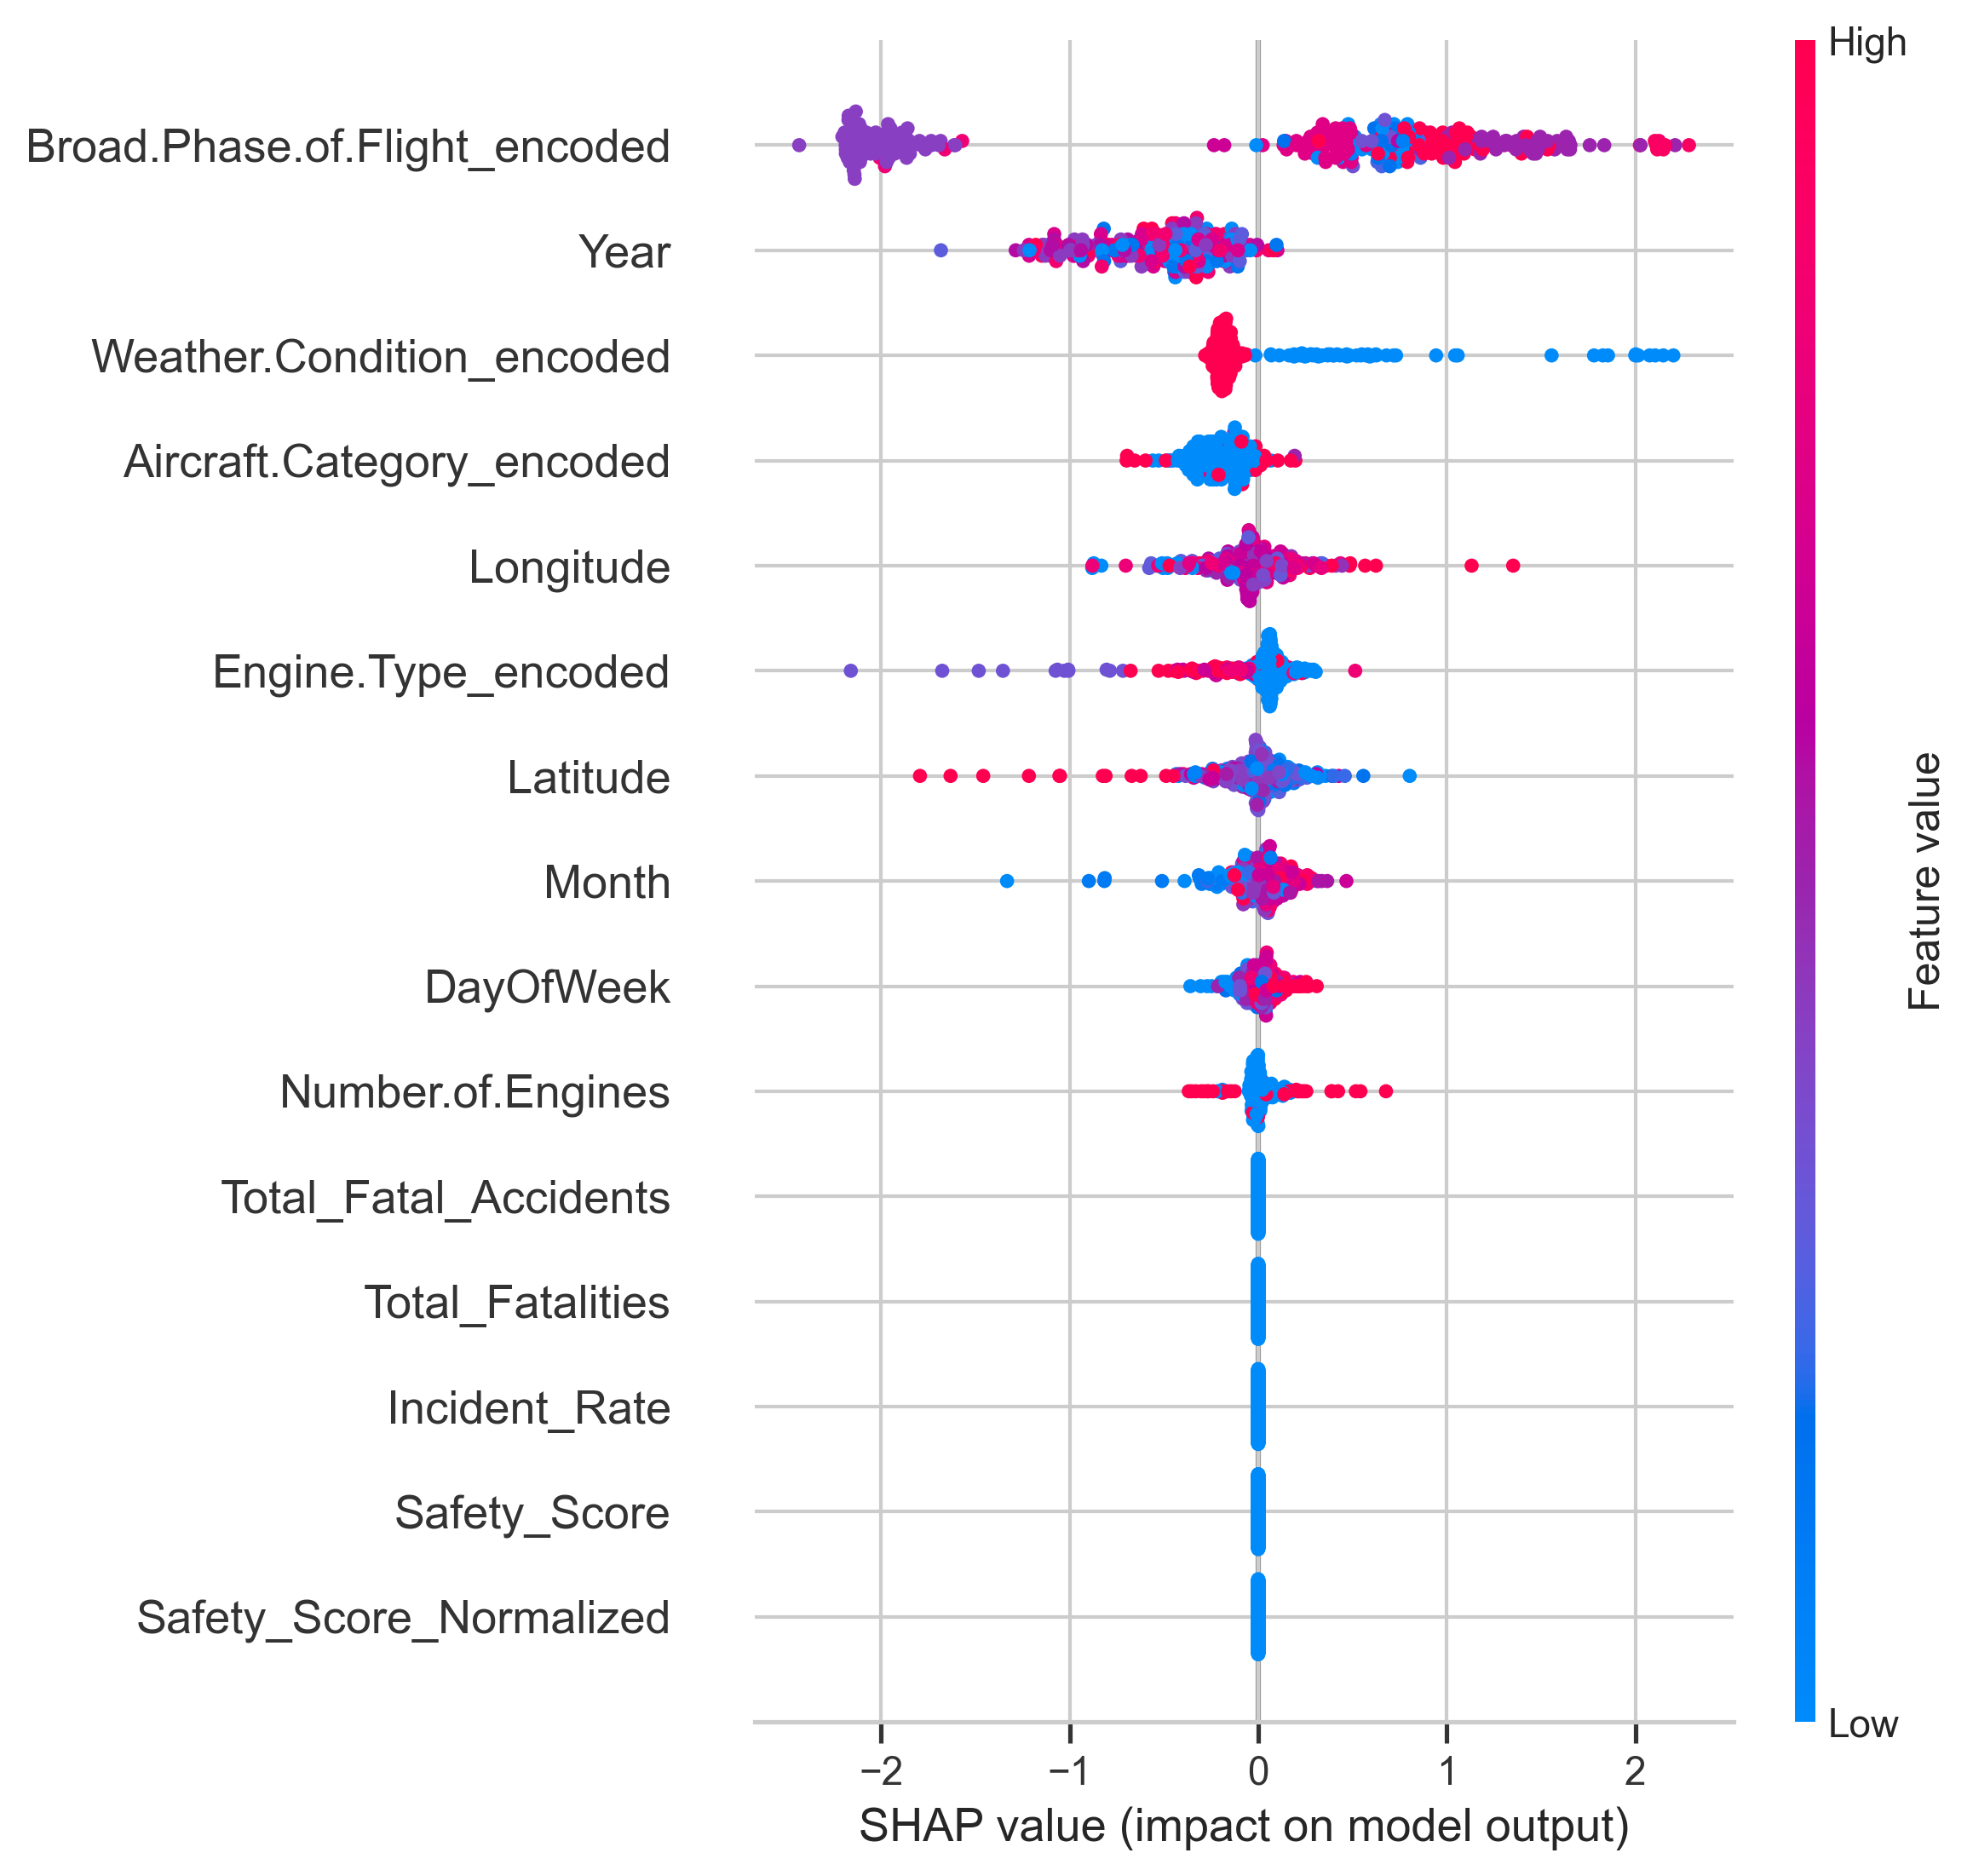

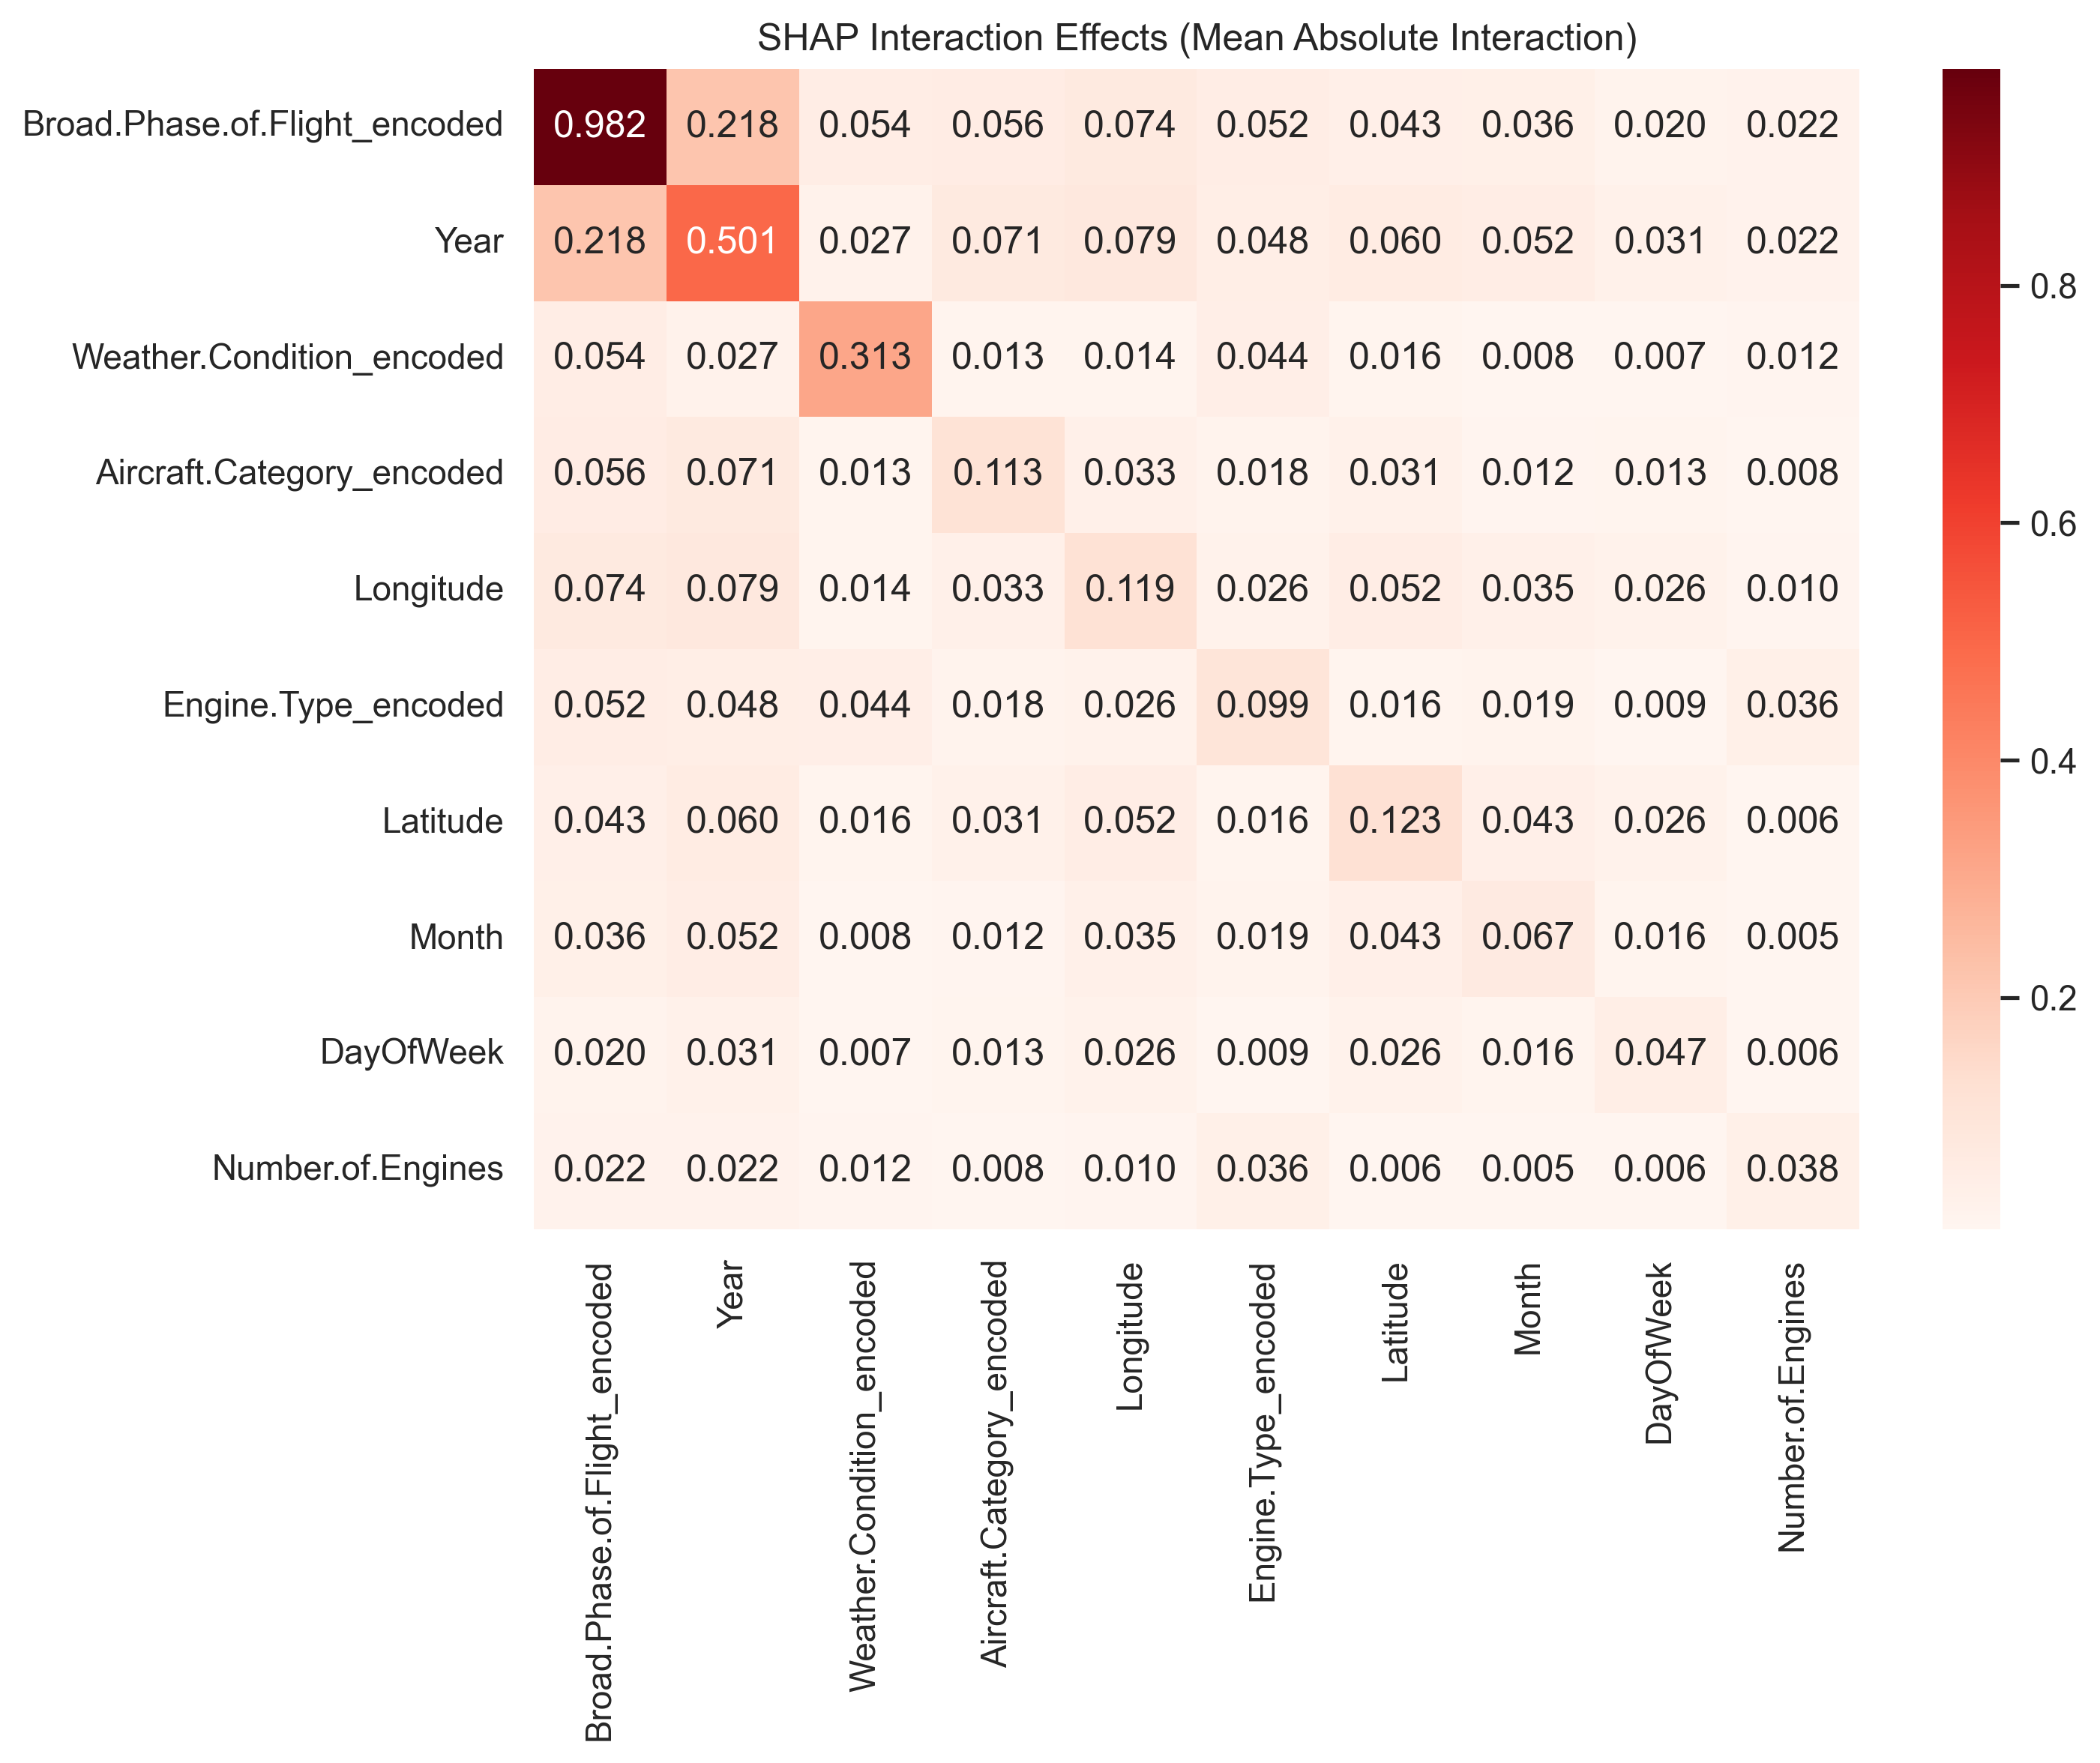

Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\shap_interaction_heatmap.png
Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\shap_interaction_matrix_top10.csv
Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\shap_summary_improved.png
Saved: D:\Projects\set_conference\aerospace\DeSek_flightproject\outputs\reviewer_revision\shap_feature_ranking_improved.csv


In [10]:
# Cell 5: SHAP main effects + SHAP interaction heatmap
if not HAS_SHAP:
    print('SHAP not installed; skipping interaction analysis.')
else:
    interaction_models = [m for m in ['LightGBM', 'RandomForest', 'ExtraTrees', 'XGBoost'] if m in models]
    if not interaction_models:
        print('No SHAP-interaction-compatible tree model available in this environment.')
    else:
        X_small = X_test.sample(min(300, len(X_test)), random_state=42)
        shap_done = False
        last_err = None

        for chosen_name in interaction_models:
            try:
                print('Trying SHAP with model:', chosen_name)
                shap_model = clone(models[chosen_name]).fit(X_train, y_train)
                core_model = shap_model.named_steps['clf'] if hasattr(shap_model, 'named_steps') else shap_model

                if hasattr(shap_model, 'named_steps') and 'imputer' in shap_model.named_steps:
                    X_small_imp = shap_model.named_steps['imputer'].transform(X_small)
                else:
                    X_small_imp = X_small.values

                feature_names = X_train.columns.tolist()
                X_small_imp = pd.DataFrame(X_small_imp, columns=feature_names)

                explainer = shap.TreeExplainer(core_model)
                shap_values = explainer.shap_values(X_small_imp)
                if isinstance(shap_values, list):
                    shap_plot_vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
                else:
                    shap_plot_vals = shap_values

                shap_rank = pd.DataFrame({
                    'feature': feature_names,
                    'mean_abs_shap': np.abs(np.asarray(shap_plot_vals)).mean(axis=0)
                }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
                display(shap_rank.head(20))
                shap_rank.to_csv(OUT_DIR / 'shap_feature_ranking_improved.csv', index=False)

                plt.figure()
                shap.summary_plot(shap_plot_vals, X_small_imp, show=False, max_display=15)
                plt.tight_layout()
                plt.savefig(OUT_DIR / 'shap_summary_improved.png', dpi=300, bbox_inches='tight')
                plt.show()

                try:
                    shap_interaction = explainer.shap_interaction_values(X_small_imp)

                    if isinstance(shap_interaction, list):
                        shap_interaction = shap_interaction[1] if len(shap_interaction) > 1 else shap_interaction[0]

                    shap_interaction = np.asarray(shap_interaction)
                    if shap_interaction.ndim == 4:
                        shap_interaction = shap_interaction[:, :, :, 1]

                    top_n = min(10, len(feature_names))
                    top_features = shap_rank.head(top_n)['feature'].tolist()
                    top_idx = [feature_names.index(f) for f in top_features]

                    interaction_subset = shap_interaction[:, top_idx, :][:, :, top_idx]
                    mean_abs_interaction = np.abs(interaction_subset).mean(axis=0)

                    interaction_df = pd.DataFrame(mean_abs_interaction, index=top_features, columns=top_features)
                    interaction_df.to_csv(OUT_DIR / 'shap_interaction_matrix_top10.csv', index=False)

                    plt.figure(figsize=(10, 8))
                    sns.heatmap(interaction_df, cmap='Reds', annot=True, fmt='.3f')
                    plt.title('SHAP Interaction Effects (Mean Absolute Interaction)')
                    plt.tight_layout()
                    plt.savefig(OUT_DIR / 'shap_interaction_heatmap.png', dpi=300, bbox_inches='tight')
                    plt.show()

                    print('Saved:', OUT_DIR / 'shap_interaction_heatmap.png')
                    print('Saved:', OUT_DIR / 'shap_interaction_matrix_top10.csv')
                except Exception as exc:
                    print('SHAP interaction generation failed:', exc)

                print('Saved:', OUT_DIR / 'shap_summary_improved.png')
                print('Saved:', OUT_DIR / 'shap_feature_ranking_improved.csv')
                shap_done = True
                break
            except Exception as exc:
                last_err = exc
                print(f'Failed with {chosen_name}:', exc)

        if not shap_done:
            print('SHAP analysis failed for all candidate models.')
            if last_err is not None:
                print('Last error:', last_err)

## Expected Outputs
- external_validation_benchmark_with_size.csv
- external_validation_benchmark.csv (updated with Model_Size_MB)
- shap_summary_improved.png (300 DPI)
- shap_feature_ranking_improved.csv
- shap_interaction_heatmap.png (300 DPI)
- shap_interaction_matrix_top10.csv